# FMNIST: how does poison rate affect a static backdoor?

Sweeping BadNets poison rate **ε** at **α = 0** and **α = 0.5** over five seeds.

In [1]:
import sys
from pathlib import Path

root = Path.cwd()
if root.name == "fmnist":
    root = root.parent
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

import matplotlib.pyplot as plt
import torch

from fmnist.experiment_setup import load_fmnist, make_model
from fmnist.algorithms import run_rgd
from fmnist import backdoor
from fmnist.plotting import save_figure

## Setup

In [20]:
TRAIN_PER_CLASS = 500
TEST_PER_CLASS = 200
N_ROUNDS = 30
LR = 0.05
EPOCHS = 1
BATCH_SIZE = 128
DEVICE = "mps" if torch.backends.mps.is_available() else "cpu"
DATA_SEED = 0

ALPHAS = [0.0, 0.5]
EPSILONS = [0.0, 0.002, 0.005, 0.01, 0.02, 0.05]
# PLOT_EPSILONS = [0.0, 0.002, 0.005, 0.01, 0.02]
PLOT_EPSILONS = [0.0, 0.05]
INSPECT_EPSILON = 0.02
EVAL_WINDOW = 5
SEEDS = [0, 1, 2, 3, 4]

TARGET_LABEL = backdoor.TARGET_LABEL
CLASS_NAMES = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

In [3]:
train_x, train_y, test_x, test_y = load_fmnist(
    data_root=str(root / "data"),
    train_per_class=TRAIN_PER_CLASS,
    test_per_class=TEST_PER_CLASS,
    seed=DATA_SEED,
)
print("train:", train_x.shape, "test:", test_x.shape)

train: torch.Size([5000, 1, 28, 28]) test: torch.Size([2000, 1, 28, 28])


## Run α x ε x seeds

In [4]:
asr_fn = backdoor.make_asr_fn(test_x, test_y, device=DEVICE)
prior_fn = backdoor.make_prior_fn(test_x, test_y, device=DEVICE)
common = dict(
    n_rounds=N_ROUNDS, lr=LR, epochs=EPOCHS,
    batch_size=BATCH_SIZE, device=DEVICE,
)

def run_clean(alpha, seed):
    model = make_model(seed=seed, device=DEVICE)
    return run_rgd(model, train_x, train_y, test_x, test_y,
                   alpha=alpha, asr_fn=asr_fn, prior_fn=prior_fn, **common)

def run_poisoned(alpha, poisoned_x, poisoned_y, seed):
    model = make_model(seed=seed, device=DEVICE)
    return run_rgd(model, poisoned_x, poisoned_y, test_x, test_y,
                   alpha=alpha, asr_fn=asr_fn, prior_fn=prior_fn, **common)

In [5]:
clean_runs = {alpha: {seed: run_clean(alpha, seed) for seed in SEEDS}
              for alpha in ALPHAS}
runs = {alpha: {epsilon: [] for epsilon in EPSILONS} for alpha in ALPHAS}
actual_rates = {epsilon: [] for epsilon in EPSILONS}

for epsilon in EPSILONS:
    for seed in SEEDS:
        # Reuse the same static poisoned tensors for both alpha values.
        poisoned_x, poisoned_y = backdoor.badnets_poison(
            train_x, train_y, poison_rate=epsilon, seed=seed + 1,
        )
        actual_rate = (poisoned_y != train_y).float().mean().item()
        actual_rates[epsilon].append(actual_rate)
        for alpha in ALPHAS:
            runs[alpha][epsilon].append(
                run_poisoned(alpha, poisoned_x, poisoned_y, seed)
            )
    print(f"ε={epsilon:.3f}  actual={sum(actual_rates[epsilon]) / len(SEEDS):.4f}")

ε=0.000  actual=0.0000
ε=0.002  actual=0.0018
ε=0.005  actual=0.0036
ε=0.010  actual=0.0090
ε=0.020  actual=0.0198
ε=0.050  actual=0.0486
ε=0.100  actual=0.0990


In [6]:
def mean_std(values):
    mean = sum(values) / len(values)
    std = (sum((value - mean) ** 2 for value in values) / len(values)) ** 0.5
    return mean, std

def tail_mean(history, value_fn):
    return sum(value_fn(row) for row in history[-EVAL_WINDOW:]) / EVAL_WINDOW

def round_mean_std(histories, value_fn):
    means, stds = [], []
    for round_idx in range(len(histories[0])):
        mean, std = mean_std([value_fn(history[round_idx]) for history in histories])
        means.append(mean)
        stds.append(std)
    return means, stds

clean_acc_stats = {}
summary_rows = {alpha: [] for alpha in ALPHAS}
for alpha in ALPHAS:
    clean_tail = [
        tail_mean(clean_runs[alpha][seed], lambda row: row["clean_acc"])
        for seed in SEEDS
    ]
    clean_acc_stats[alpha] = mean_std(clean_tail)
    for epsilon in EPSILONS:
        histories = runs[alpha][epsilon]
        asr_mean, asr_std = mean_std([tail_mean(h, lambda row: row["asr"]) for h in histories])
        prior_mean, prior_std = mean_std([tail_mean(h, lambda row: row["prior_rate"]) for h in histories])
        acc_mean, acc_std = mean_std([tail_mean(h, lambda row: row["clean_acc"]) for h in histories])
        target_acc_mean, target_acc_std = mean_std([
            tail_mean(h, lambda row: row["per_class_acc"][TARGET_LABEL]) for h in histories
        ])
        target_weight_mean, target_weight_std = mean_std([
            tail_mean(h, lambda row: row["class_mix"][TARGET_LABEL]) for h in histories
        ])
        actual_mean, actual_std = mean_std(actual_rates[epsilon])
        summary_rows[alpha].append({
            "epsilon": epsilon, "actual_epsilon": actual_mean, "actual_epsilon_std": actual_std,
            "asr_mean": asr_mean, "asr_std": asr_std,
            "prior_mean": prior_mean, "prior_std": prior_std,
            "acc_mean": acc_mean, "acc_std": acc_std,
            "target_acc_mean": target_acc_mean, "target_acc_std": target_acc_std,
            "target_weight_mean": target_weight_mean, "target_weight_std": target_weight_std,
        })
        print(f"α={alpha:g}  ε={epsilon:.3f}  ASR={asr_mean:.3f}±{asr_std:.3f}  "
              f"target acc={target_acc_mean:.3f}±{target_acc_std:.3f}  "
              f"target weight={target_weight_mean:.3f}±{target_weight_std:.3f}")

α=0  ε=0.000  ASR=0.018±0.003  target acc=0.787±0.025  target weight=0.100±0.000
α=0  ε=0.002  ASR=0.081±0.015  target acc=0.778±0.018  target weight=0.100±0.000
α=0  ε=0.005  ASR=0.349±0.012  target acc=0.758±0.018  target weight=0.100±0.000
α=0  ε=0.010  ASR=0.816±0.033  target acc=0.790±0.020  target weight=0.100±0.000
α=0  ε=0.020  ASR=0.954±0.011  target acc=0.797±0.030  target weight=0.100±0.000
α=0  ε=0.050  ASR=0.992±0.005  target acc=0.774±0.017  target weight=0.100±0.000
α=0  ε=0.100  ASR=0.997±0.002  target acc=0.803±0.026  target weight=0.100±0.000
α=0.5  ε=0.000  ASR=0.016±0.002  target acc=0.746±0.026  target weight=0.104±0.002
α=0.5  ε=0.002  ASR=0.066±0.017  target acc=0.759±0.030  target weight=0.104±0.001
α=0.5  ε=0.005  ASR=0.305±0.025  target acc=0.762±0.017  target weight=0.104±0.001
α=0.5  ε=0.010  ASR=0.799±0.053  target acc=0.771±0.013  target weight=0.103±0.001
α=0.5  ε=0.020  ASR=0.948±0.018  target acc=0.777±0.030  target weight=0.103±0.002
α=0.5  ε=0.050  AS

## Poisoning effect

saved: /Users/tets/Documents/GitHub/poison-perf/fmnist/results/epsilon_sweep_alpha0_vs_alpha0.5_20260722_124250.png


PosixPath('/Users/tets/Documents/GitHub/poison-perf/fmnist/results/epsilon_sweep_alpha0_vs_alpha0.5_20260722_124250.png')

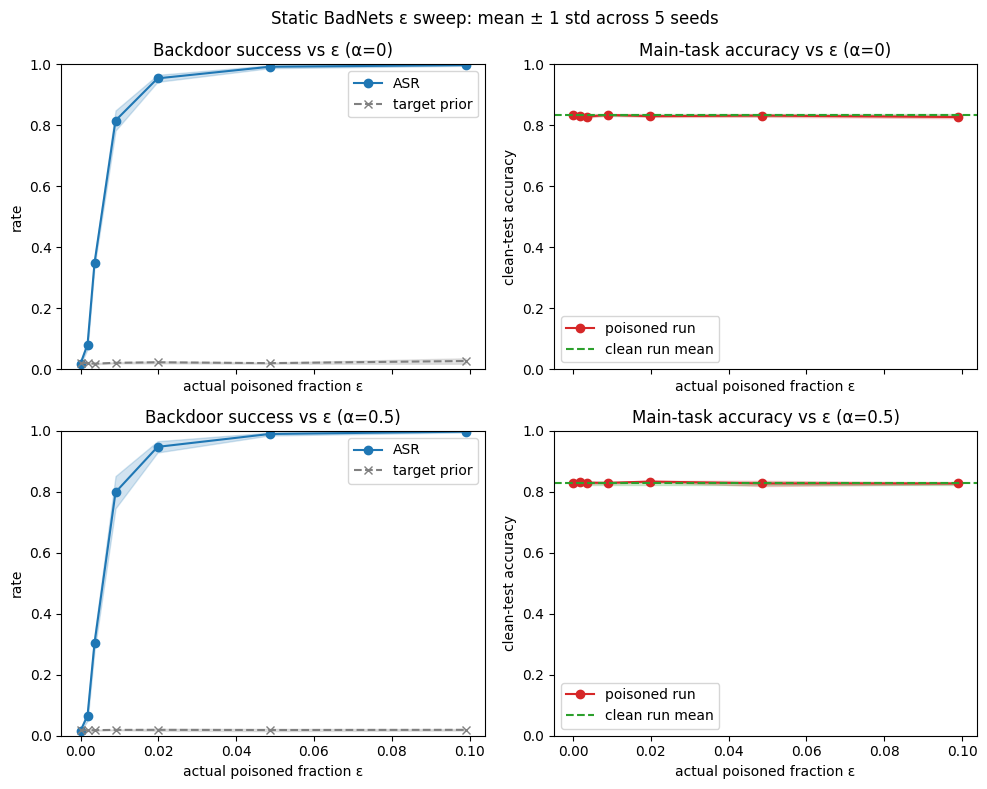

In [7]:
def plot_band(ax, x, mean, std, **kwargs):
    line, = ax.plot(x, mean, **kwargs)
    ax.fill_between(x, [m - s for m, s in zip(mean, std)],
                    [m + s for m, s in zip(mean, std)],
                    color=line.get_color(), alpha=0.2)

fig, axes = plt.subplots(len(ALPHAS), 2, figsize=(10, 4 * len(ALPHAS)),
                         sharex=True, sharey="col", squeeze=False)
for row_idx, alpha in enumerate(ALPHAS):
    rows = summary_rows[alpha]
    x = [row["actual_epsilon"] for row in rows]
    ax1, ax2 = axes[row_idx]
    plot_band(ax1, x, [row["asr_mean"] for row in rows],
              [row["asr_std"] for row in rows], marker="o", label="ASR")
    plot_band(ax1, x, [row["prior_mean"] for row in rows],
              [row["prior_std"] for row in rows], marker="x",
              linestyle="--", color="gray", label="target prior")
    ax1.set(xlabel="actual poisoned fraction ε", ylabel="rate", ylim=(0, 1),
            title=f"Backdoor success vs ε (α={alpha:g})")
    ax1.legend()

    plot_band(ax2, x, [row["acc_mean"] for row in rows],
              [row["acc_std"] for row in rows], marker="o",
              color="tab:red", label="poisoned run")
    clean_acc_mean, clean_acc_std = clean_acc_stats[alpha]
    ax2.axhline(clean_acc_mean, color="tab:green", linestyle="--", label="clean run mean")
    ax2.fill_between(x, clean_acc_mean - clean_acc_std, clean_acc_mean + clean_acc_std,
                     color="tab:green", alpha=0.2)
    ax2.set(xlabel="actual poisoned fraction ε", ylabel="clean-test accuracy", ylim=(0, 1),
            title=f"Main-task accuracy vs ε (α={alpha:g})")
    ax2.legend()
fig.suptitle(f"Static BadNets ε sweep: mean ± 1 std across {len(SEEDS)} seeds")
fig.tight_layout()
save_figure(fig, "epsilon_sweep_alpha0_vs_alpha0.5")

## Target-class dynamics

saved: /Users/tets/Documents/GitHub/poison-perf/fmnist/results/target_class_dynamics_alpha0_vs_alpha0.5_20260722_130215.png


PosixPath('/Users/tets/Documents/GitHub/poison-perf/fmnist/results/target_class_dynamics_alpha0_vs_alpha0.5_20260722_130215.png')

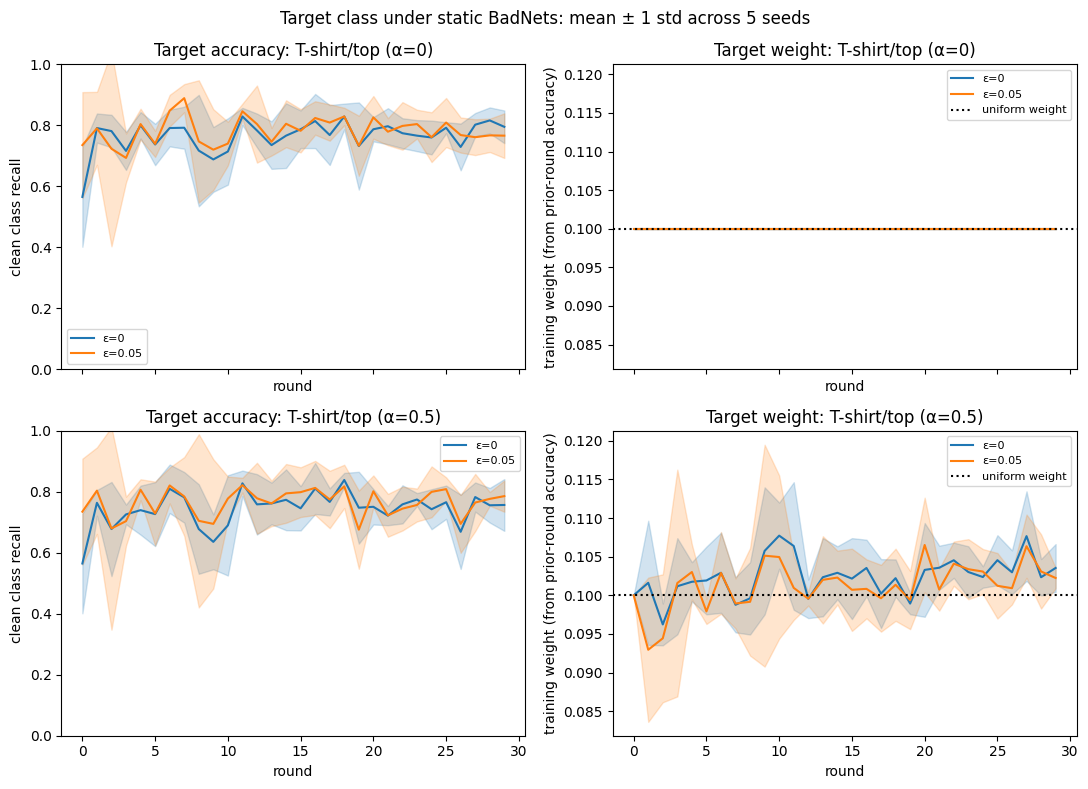

In [21]:
rounds = [row["round"] for row in runs[ALPHAS[0]][PLOT_EPSILONS[0]][0]]
fig, axes = plt.subplots(len(ALPHAS), 2, figsize=(11, 4 * len(ALPHAS)),
                         sharex=True, sharey="col", squeeze=False)
for row_idx, alpha in enumerate(ALPHAS):
    ax1, ax2 = axes[row_idx]
    for epsilon in PLOT_EPSILONS:
        histories = runs[alpha][epsilon]
        acc_mean, acc_std = round_mean_std(
            histories, lambda row: row["per_class_acc"][TARGET_LABEL],
        )
        weight_mean, weight_std = round_mean_std(
            histories, lambda row: row["class_mix"][TARGET_LABEL],
        )
        plot_band(ax1, rounds, acc_mean, acc_std, label=f"ε={epsilon:g}")
        plot_band(ax2, rounds, weight_mean, weight_std, label=f"ε={epsilon:g}")

    ax1.set(xlabel="round", ylabel="clean class recall", ylim=(0, 1),
            title=f"Target accuracy: {CLASS_NAMES[TARGET_LABEL]} (α={alpha:g})")
    ax2.axhline(0.1, color="black", linestyle=":", label="uniform weight")
    ax2.set(xlabel="round", ylabel="training weight (from prior-round accuracy)",
            title=f"Target weight: {CLASS_NAMES[TARGET_LABEL]} (α={alpha:g})")
    ax1.legend(fontsize=8)
    ax2.legend(fontsize=8)
fig.suptitle(f"Target class under static BadNets: mean ± 1 std across {len(SEEDS)} seeds")
fig.tight_layout()
save_figure(fig, "target_class_dynamics_alpha0_vs_alpha0.5")

saved: /Users/tets/Documents/GitHub/poison-perf/fmnist/results/class_weights_alpha0_vs_alpha0.5_eps0.02_20260722_130219.png


PosixPath('/Users/tets/Documents/GitHub/poison-perf/fmnist/results/class_weights_alpha0_vs_alpha0.5_eps0.02_20260722_130219.png')

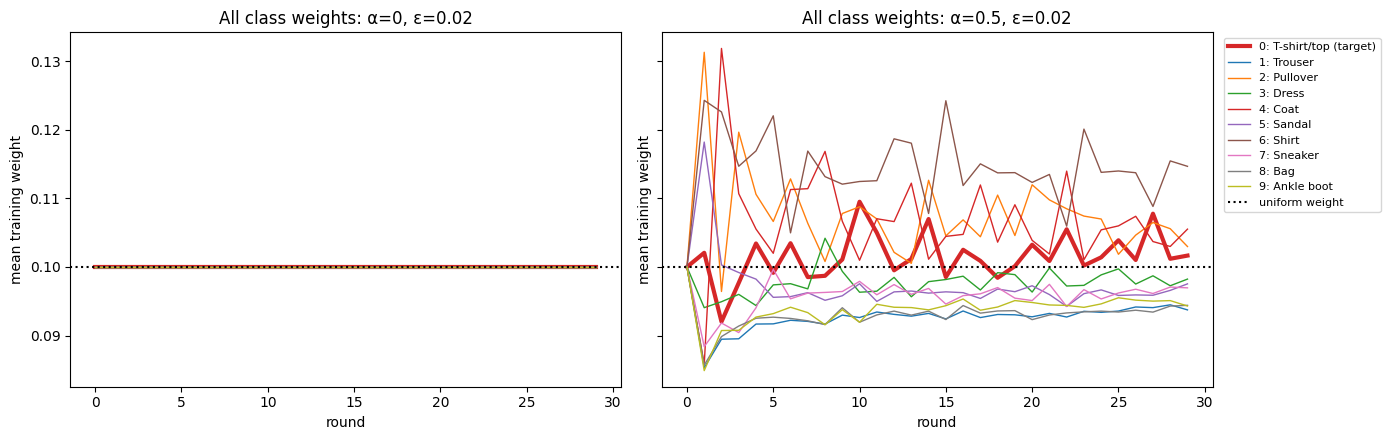

In [22]:
fig, axes = plt.subplots(1, len(ALPHAS), figsize=(7 * len(ALPHAS), 4.5),
                         sharex=True, sharey=True, squeeze=False)
for ax, alpha in zip(axes[0], ALPHAS):
    histories = runs[alpha][INSPECT_EPSILON]
    for class_idx, class_name in enumerate(CLASS_NAMES):
        weight_mean, _ = round_mean_std(
            histories, lambda row, c=class_idx: row["class_mix"][c],
        )
        is_target = class_idx == TARGET_LABEL
        ax.plot(rounds, weight_mean, linewidth=3 if is_target else 1,
                color="tab:red" if is_target else None,
                label=f"{class_idx}: {class_name}" + (" (target)" if is_target else ""))
    ax.axhline(0.1, color="black", linestyle=":", label="uniform weight")
    ax.set(xlabel="round", ylabel="mean training weight",
           title=f"All class weights: α={alpha:g}, ε={INSPECT_EPSILON}")
axes[0, -1].legend(loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=8)
fig.tight_layout()
save_figure(fig, f"class_weights_alpha0_vs_alpha0.5_eps{INSPECT_EPSILON}")